# Deep CNN - dataset, transform and visualize


# dataset loading and visualize

In [19]:
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import time
import copy
import os
import torchvision.models as models

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [14]:
mean = (0.4914, 0.4822, 0.4465)
std = (0.2470, 0.2435, 0.2616)


train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

In [15]:
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=train_transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=test_transform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=128, shuffle=False)

classes = trainset.classes
print("Classes:", classes)

Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [16]:
def imshow(img):
    img = img / 2 + 0.5
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

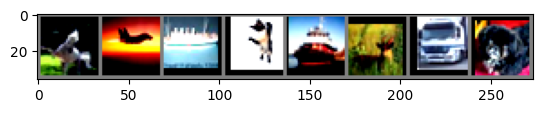

horse      airplane   ship       cat        ship       deer       truck      dog       


In [17]:
dataiter = iter(trainloader)
images, labels = next(dataiter)


imshow(torchvision.utils.make_grid(images[:8]))

print(' '.join(f'{classes[labels[j]]:10s}' for j in range(8)))

# VGG 16 model

In [20]:
model = models.vgg16(pretrained=False)

In [21]:
model.classifier[6] = nn.Linear(4096, 10)

In [24]:
model = model.to(device)
print("Model loaded", device)
print(model)

Model loaded cuda
VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, pad

In [25]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
#activations


In [27]:
num_epochs = 20
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for i, (images, labels) in enumerate(trainloader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        if (i+1) % 100 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{len(trainloader)}], "
                  f"Loss: {running_loss/100:.4f}, Acc: {100*correct/total:.2f}%")
            running_loss = 0.0

print("done")


Epoch [1/10], Step [100/391], Loss: 2.3006, Acc: 10.38%
Epoch [1/10], Step [200/391], Loss: 2.2960, Acc: 10.49%
Epoch [1/10], Step [300/391], Loss: 2.2830, Acc: 10.64%
Epoch [2/10], Step [100/391], Loss: 2.1879, Acc: 18.68%
Epoch [2/10], Step [200/391], Loss: 2.0774, Acc: 20.70%
Epoch [2/10], Step [300/391], Loss: 2.0219, Acc: 21.79%
Epoch [3/10], Step [100/391], Loss: 1.8802, Acc: 29.02%
Epoch [3/10], Step [200/391], Loss: 1.8543, Acc: 29.52%
Epoch [3/10], Step [300/391], Loss: 1.8224, Acc: 29.98%
Epoch [4/10], Step [100/391], Loss: 1.7520, Acc: 33.67%
Epoch [4/10], Step [200/391], Loss: 1.7077, Acc: 34.32%
Epoch [4/10], Step [300/391], Loss: 1.6685, Acc: 35.13%
Epoch [5/10], Step [100/391], Loss: 1.5829, Acc: 40.74%
Epoch [5/10], Step [200/391], Loss: 1.5769, Acc: 41.03%
Epoch [5/10], Step [300/391], Loss: 1.5403, Acc: 41.68%
Epoch [6/10], Step [100/391], Loss: 1.5002, Acc: 44.48%
Epoch [6/10], Step [200/391], Loss: 1.4639, Acc: 45.04%
Epoch [6/10], Step [300/391], Loss: 1.4339, Acc:

In [28]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

print(f"Test Accuracy: {100 * correct / total:.2f}%")


Test Accuracy: 62.78%


# Resnet 18 model

In [29]:
model = models.resnet18(pretrained=True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 196MB/s]


In [30]:
in_features = model.fc.in_features
model.fc = nn.Linear(in_features, 10)

model = model.to(device)
print("model load:", device)
print(model)

model load: cuda
ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU

In [31]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

In [32]:
num_epochs = 20
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for i, (images, labels) in enumerate(trainloader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        if (i+1) % 100 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{len(trainloader)}], "
                  f"Loss: {running_loss/100:.4f}, Acc: {100*correct/total:.2f}%")
            running_loss = 0.0

print("done")


Epoch [1/20], Step [100/391], Loss: 1.7674, Acc: 37.56%
Epoch [1/20], Step [200/391], Loss: 1.3058, Acc: 45.75%
Epoch [1/20], Step [300/391], Loss: 1.1488, Acc: 50.20%
Epoch [2/20], Step [100/391], Loss: 0.9641, Acc: 65.59%
Epoch [2/20], Step [200/391], Loss: 0.9180, Acc: 66.41%
Epoch [2/20], Step [300/391], Loss: 0.8694, Acc: 67.53%
Epoch [3/20], Step [100/391], Loss: 0.8107, Acc: 71.49%
Epoch [3/20], Step [200/391], Loss: 0.7813, Acc: 72.21%
Epoch [3/20], Step [300/391], Loss: 0.7613, Acc: 72.59%
Epoch [4/20], Step [100/391], Loss: 0.7199, Acc: 74.85%
Epoch [4/20], Step [200/391], Loss: 0.7055, Acc: 75.10%
Epoch [4/20], Step [300/391], Loss: 0.6737, Acc: 75.52%
Epoch [5/20], Step [100/391], Loss: 0.6385, Acc: 77.79%
Epoch [5/20], Step [200/391], Loss: 0.6451, Acc: 77.68%
Epoch [5/20], Step [300/391], Loss: 0.6246, Acc: 77.81%
Epoch [6/20], Step [100/391], Loss: 0.6007, Acc: 78.85%
Epoch [6/20], Step [200/391], Loss: 0.6118, Acc: 78.91%
Epoch [6/20], Step [300/391], Loss: 0.5904, Acc:

In [33]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

print(f"test Accuracy {100 * correct / total:.2f}%")


test Accuracy 83.22%


# google net model

In [35]:
model = models.googlenet(pretrained=True, aux_logits=True)

model.fc = nn.Linear(model.fc.in_features, 10)
model.aux1.fc2 = nn.Linear(model.aux1.fc2.in_features, 10)
model.aux2.fc2 = nn.Linear(model.aux2.fc2.in_features, 10)

model = model.to(device)
print("GoogLeNet loaded on:", device)
print(model)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=GoogLeNet_Weights.IMAGENET1K_V1`. You can also use `weights=GoogLeNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


GoogLeNet loaded on: cuda
GoogLeNet(
  (conv1): BasicConv2d(
    (conv): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (conv2): BasicConv2d(
    (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (conv3): BasicConv2d(
    (conv): Conv2d(64, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(192, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (inception3a): Inception(
    (branch1): BasicConv2d(
      (conv): Conv2d(192, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=0.001, moment

/usr/local/lib/python3.12/dist-packages/torchvision/models/googlenet.py:341: UserWarning: auxiliary heads in the pretrained googlenet model are NOT pretrained, so make sure to train them
  warnings.warn(


In [36]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)


In [37]:
num_epochs = 20

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for i, (images, labels) in enumerate(trainloader):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()


        outputs, aux1, aux2 = model(images)
        loss1 = criterion(outputs, labels)
        loss2 = criterion(aux1, labels)
        loss3 = criterion(aux2, labels)
        loss = loss1 + 0.3 * (loss2 + loss3)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        if (i+1) % 100 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{len(trainloader)}], "
                  f"Loss: {running_loss/100:.4f}, Acc: {100*correct/total:.2f}%")
            running_loss = 0.0

print("done")


Epoch [1/20], Step [100/391], Loss: 3.1857, Acc: 29.88%
Epoch [1/20], Step [200/391], Loss: 2.2219, Acc: 40.73%
Epoch [1/20], Step [300/391], Loss: 1.8652, Acc: 47.04%
Epoch [2/20], Step [100/391], Loss: 1.5443, Acc: 66.71%
Epoch [2/20], Step [200/391], Loss: 1.4700, Acc: 67.75%
Epoch [2/20], Step [300/391], Loss: 1.3667, Acc: 68.87%
Epoch [3/20], Step [100/391], Loss: 1.2457, Acc: 73.54%
Epoch [3/20], Step [200/391], Loss: 1.2467, Acc: 73.41%
Epoch [3/20], Step [300/391], Loss: 1.2060, Acc: 73.89%
Epoch [4/20], Step [100/391], Loss: 1.1127, Acc: 76.22%
Epoch [4/20], Step [200/391], Loss: 1.0946, Acc: 76.53%
Epoch [4/20], Step [300/391], Loss: 1.0527, Acc: 76.84%
Epoch [5/20], Step [100/391], Loss: 0.9911, Acc: 78.88%
Epoch [5/20], Step [200/391], Loss: 1.0039, Acc: 78.92%
Epoch [5/20], Step [300/391], Loss: 1.0014, Acc: 78.95%
Epoch [6/20], Step [100/391], Loss: 0.9044, Acc: 81.27%
Epoch [6/20], Step [200/391], Loss: 0.9361, Acc: 80.74%
Epoch [6/20], Step [300/391], Loss: 0.9095, Acc:

In [38]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
     
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

print(f"Test Accuracy{100 * correct / total:.2f}%")


Test Accuracy84.33%


# Occlusion Analysis

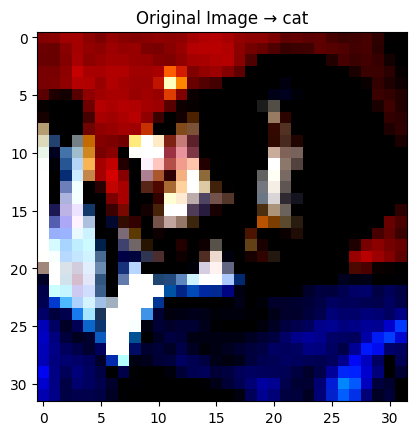

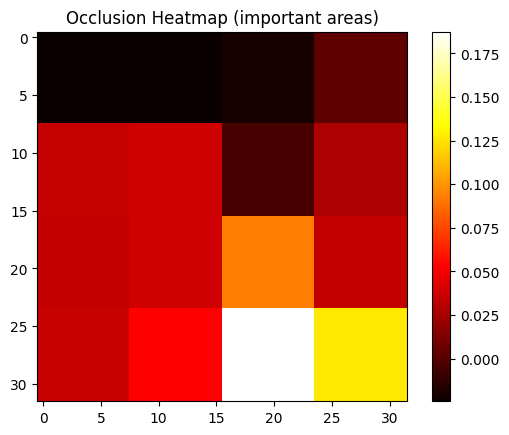

In [42]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
classes = ['plane', 'car', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck']

def occlusion_analysis(model, image, label, patch_size=8):
    model.eval()
    image = image.unsqueeze(0).to(device)
    _, _, H, W = image.shape
    heatmap = torch.zeros((H, W))


    with torch.no_grad():
        orig_output = model(image)
        orig_prob = F.softmax(orig_output, dim=1)[0, label].item()


    for y in range(0, H, patch_size):
        for x in range(0, W, patch_size):
            occluded = image.clone()
            occluded[:, :, y:y+patch_size, x:x+patch_size] = 0  # mask patch
            with torch.no_grad():
                output = model(occluded)
                prob = F.softmax(output, dim=1)[0, label].item()
            heatmap[y:y+patch_size, x:x+patch_size] = orig_prob - prob

    return heatmap.cpu().numpy()


dataiter = iter(testloader)


images, labels = next(dataiter)
image = images[0]
label = labels[0]

heatmap = occlusion_analysis(model, image, label, patch_size=8)

plt.imshow(np.transpose(image.numpy(), (1, 2, 0)))
plt.title(f"Original Image → {classes[label]}")

plt.show()

plt.imshow(heatmap, cmap='hot')
plt.title("Occlusion Heatmap (important areas)")
plt.colorbar()
plt.show()
